# Gemma-3 Benchmark Analysis

This notebook benchmarks the performance of various `google/gemma-3` models in generating semantic channel descriptions. It compares the description-induced channel topology against the ground truth point cloud topology derived from 20D video-title embeddings.

## 1) Setup & Dependencies
Install requirements, mount Google Drive, and import necessary libraries.

In [18]:
import os
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

# Install FFmpeg and its development libraries to resolve torchcodec dependency issues with sentence-transformers
!apt-get update -qq && apt-get install -y ffmpeg libavutil-dev libavcodec-dev libavformat-dev
!pip install -q pandas numpy scipy sentence-transformers matplotlib seaborn

# Uninstall torchcodec if it causes issues, as it's not needed for text models
!pip uninstall -y torchcodec || true

# Import SentenceTransformer after installation to ensure dependencies are met
from sentence_transformers import SentenceTransformer

try:
    from google.colab import ai
except ImportError:
    pass

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    print('Not running in Colab. Falling back to local execution.')
    IN_COLAB = False

sns.set_theme(style='whitegrid', context='notebook')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavcodec-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavformat-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavutil-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.
Found existing installation: torchcodec 0.10.0
Uninstalling torchcodec-0.10.0:
  Successfully uninstalled torchcodec-0.10.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Configuration
Define target models, data paths, and output locations.

In [5]:
MODELS = [
  'google/gemini-2.5-flash',
  'google/gemini-2.5-flash-lite',
]

DRIVE_ROOT = Path('/content/drive/MyDrive')
GRAPHIKO_ROOT = DRIVE_ROOT / 'Graphiko'

VIDEO_EMBEDDINGS_CSV = (
    GRAPHIKO_ROOT
    / 'exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv'
)

BENCHMARK_OUTPUT_DIR = GRAPHIKO_ROOT / 'research/benchmark/latest'
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHED_DESCRIPTIONS_PATH = BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_descriptions.json'
RESULTS_SUMMARY_PATH = BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_results.csv'

print(f'Target Models: {MODELS}')
print(f'Output Directory: {BENCHMARK_OUTPUT_DIR}')

Target Models: ['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite']
Output Directory: /content/drive/MyDrive/Graphiko/research/benchmark/latest


## 3) Load 20D Video-Title Embeddings
Load the canonical reduced video embeddings and compute channel centroids to serve as the ground truth topology.

In [6]:
def load_video_title_embeddings(path: Path):
    if not path.exists():
        print(f'Warning: {path} not found. Creating dummy data for testing.')
        # Dummy data for local execution / testing
        channels = ['20VC with Harry Stebbings', 'ARK Invest', 'Alex Hormozi', 'All-In Podcast', 'Anthony Pompliano']
        data = []
        for ch in channels:
            for i in range(10):
                row = {'channel_name': ch, 'video_title': f'{ch} Video {i}'}
                for d in range(1, 21):
                    row[f'embedding_reduced_{d:02d}'] = np.random.randn()
                data.append(row)
        return pd.DataFrame(data), [f'embedding_reduced_{i:02d}' for i in range(1, 21)]

    df = pd.read_csv(path)
    embedding_cols = [f'embedding_reduced_{i:02d}' for i in range(1, 21)]
    return df, embedding_cols

videos_df, EMBEDDING_COLS = load_video_title_embeddings(VIDEO_EMBEDDINGS_CSV)
print(f'Loaded {len(videos_df)} videos across {videos_df["channel_name"].nunique()} channels.')

def compute_ground_truth_similarity(df, cols):
    from sklearn.metrics.pairwise import cosine_similarity
    centroids = df.groupby('channel_name')[cols].mean()
    sim_matrix = pd.DataFrame(
        cosine_similarity(centroids.values),
        index=centroids.index,
        columns=centroids.index
    )
    return centroids, sim_matrix

channel_centroids, title_similarity = compute_ground_truth_similarity(videos_df, EMBEDDING_COLS)
print(f'Ground truth similarity matrix computed: {title_similarity.shape}')

Loaded 1344 videos across 27 channels.
Ground truth similarity matrix computed: (27, 27)


## 4) Generate Channel Descriptions
Iterate through channels and models to generate semantic descriptions using the Jules prompt. Intermediate results are cached to a JSON file.

In [10]:
def generate_jules_description(channel_name, video_titles, model_name):
    if not IN_COLAB:
        return {"description": f"Dummy description for {channel_name} using {model_name}."}

    # Limit to avoid token limits
    titles_str = ', '.join(video_titles[:50])
    print(f'Generating description for {channel_name} using {model_name}...')
    prompt = f"""
You    You are an expert content analyst. Analyze the following list of video titles for the YouTube channel '{channel_name}'.
    Titles: {titles_str}

    Provide a comprehensive summary of the channel's main themes and style.
    """
    try:
        response = ai.generate_text(prompt, model_name=model_name)
        raw_text = response.strip()
        # The user requested to remove JSON parsing, so we directly return the text.
        return {"description": raw_text}
    except Exception as e:
        print(f'Error generating with {model_name} for {channel_name}: {e}')
        return None

if CACHED_DESCRIPTIONS_PATH.exists():
    with open(CACHED_DESCRIPTIONS_PATH, 'r') as f:
        benchmark_results = json.load(f)
    print('Loaded existing cached descriptions.')
else:
    benchmark_results = {}

for model in MODELS:
    if model not in benchmark_results:
        benchmark_results[model] = {}

    print(f'Starting generation for model: {model}')
    for channel_name, group in videos_df.groupby('channel_name'):
        if channel_name in benchmark_results[model]:
            continue

        titles = group['video_title'].tolist()
        desc_data = generate_jules_description(channel_name, titles, model)
        if desc_data:
            benchmark_results[model][channel_name] = desc_data
            # Save intermediate results
            with open(CACHED_DESCRIPTIONS_PATH, 'w') as f:
                json.dump(benchmark_results, f, indent=2)

        if IN_COLAB:
            time.sleep(2) # Respect rate limits

print('Description generation complete.')

Loaded existing cached descriptions.
Starting generation for model: google/gemini-2.5-flash
Generating description for Garry Tan using google/gemini-2.5-flash...
Generating description for Greg Isenberg using google/gemini-2.5-flash...
Generating description for Joe Lonsdale using google/gemini-2.5-flash...
Generating description for Lenny's Podcast using google/gemini-2.5-flash...
Generating description for My First Million using google/gemini-2.5-flash...
Generating description for Network State Podcast using google/gemini-2.5-flash...
Generating description for Patrick Boyle using google/gemini-2.5-flash...
Generating description for Peter H. Diamandis using google/gemini-2.5-flash...
Generating description for Principles by Ray Dalio using google/gemini-2.5-flash...
Generating description for Real Vision Presents using google/gemini-2.5-flash...
Generating description for Sequoia Capital using google/gemini-2.5-flash...
Generating description for The Prof G Pod – Scott Galloway usi

## 5) Compute Description Embeddings and Similarity Matrices
Encode the generated descriptions for each model using `all-MiniLM-L6-v2` and compute the corresponding channel similarity matrices.

In [19]:

print('Loading SentenceTransformer model...')
st_model = SentenceTransformer('all-MiniLM-L6-v2')

model_similarity_matrices = {}

for model in MODELS:
    print(f'Computing embeddings and similarity matrix for model: {model}')

    channel_names = []
    descriptions = []

    # Ensure we use the same channel order as the ground truth
    ordered_channels = sorted(title_similarity.index)

    for ch in ordered_channels:
        desc_data = benchmark_results.get(model, {}).get(ch)
        if desc_data and 'description' in desc_data:
            channel_names.append(ch)
            descriptions.append(desc_data['description'])

    if not descriptions:
        print(f'No descriptions found for model {model}. Skipping.')
        continue

    embeddings = st_model.encode(descriptions, normalize_embeddings=True)

    # Cosine similarity is dot product of normalized embeddings
    sim_values = np.dot(embeddings, embeddings.T)

    sim_matrix = pd.DataFrame(
        sim_values,
        index=channel_names,
        columns=channel_names
    )

    model_similarity_matrices[model] = sim_matrix
    print(f'Matrix computed for {model}: {sim_matrix.shape}')

Loading SentenceTransformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing embeddings and similarity matrix for model: google/gemini-2.5-flash
Matrix computed for google/gemini-2.5-flash: (27, 27)
Computing embeddings and similarity matrix for model: google/gemini-2.5-flash-lite
Matrix computed for google/gemini-2.5-flash-lite: (27, 27)


## 6) Correlation Analysis
Compare each model's description-induced similarity matrix against the video-title ground truth matrix using Pearson, Spearman, and Kendall-tau correlations.

In [20]:
def align_matrices(left: pd.DataFrame, right: pd.DataFrame):
    common = sorted(set(left.index) & set(right.index))
    return left.loc[common, common], right.loc[common, common]

def upper_triangle_values(matrix: pd.DataFrame):
    vals = matrix.to_numpy(dtype=float)
    mask = np.triu(np.ones(vals.shape, dtype=bool), k=1)
    return vals[mask]

def safe_correlation(fn, x, y):
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    stat = fn(x, y)
    return float(stat.statistic), float(stat.pvalue)

results = []

for model, sim_matrix in model_similarity_matrices.items():
    print(f'Analyzing model: {model}')

    m_aligned, t_aligned = align_matrices(sim_matrix, title_similarity)

    m_vals = upper_triangle_values(m_aligned)
    t_vals = upper_triangle_values(t_aligned)

    p_corr, p_p = safe_correlation(pearsonr, m_vals, t_vals)
    s_corr, s_p = safe_correlation(spearmanr, m_vals, t_vals)
    k_corr, k_p = safe_correlation(kendalltau, m_vals, t_vals)

    results.append({
        'model': model,
        'n_channels': m_aligned.shape[0],
        'pearson_corr': p_corr,
        'spearman_corr': s_corr,
        'kendall_corr': k_corr
    })

benchmark_df = pd.DataFrame(results).sort_values('spearman_corr', ascending=False)
benchmark_df.to_csv(RESULTS_SUMMARY_PATH, index=False)
benchmark_df

Analyzing model: google/gemini-2.5-flash
Analyzing model: google/gemini-2.5-flash-lite


,model,n_channels,pearson_corr,spearman_corr,kendall_corr
1,google/gemini-2.5-flash-lite,27,0.323312,0.320469,0.216931
0,google/gemini-2.5-flash,27,0.294848,0.276738,0.180659


## 7) Results Visualization
Visualize the benchmarking results using bar charts to compare the performance of different Gemma-3 models.

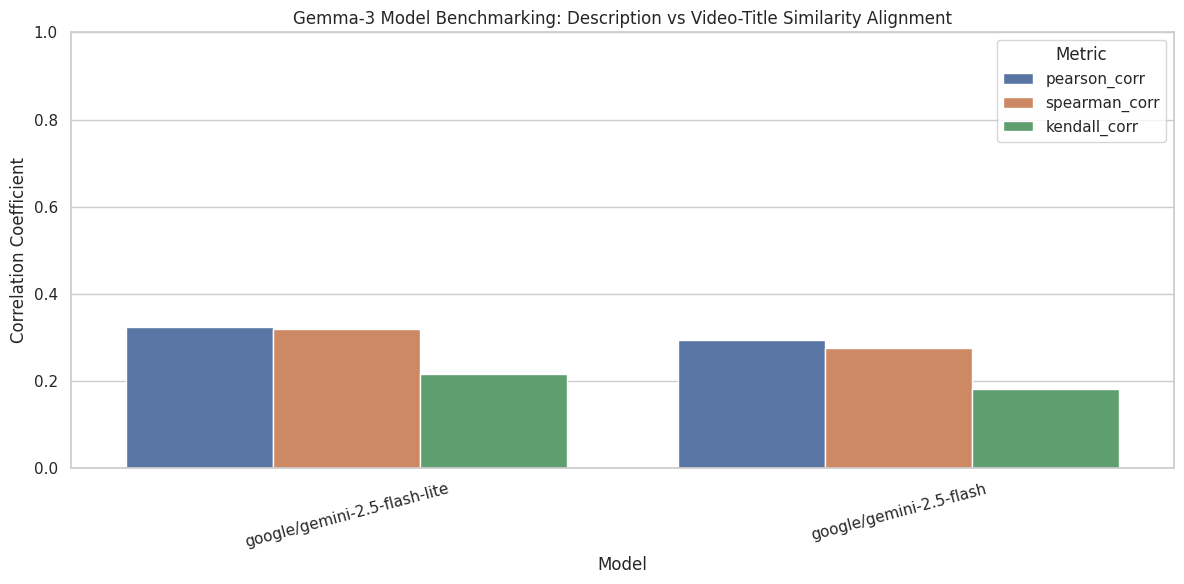

In [21]:
metrics = ['pearson_corr', 'spearman_corr', 'kendall_corr']
df_melted = benchmark_df.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='correlation')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='model', y='correlation', hue='metric')
plt.title('Gemma-3 Model Benchmarking: Description vs Video-Title Similarity Alignment')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_comparison.png', dpi=160)
plt.show()